In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [2]:
X_moons, _ = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)

X_circles, _ = make_circles(
    n_samples=300,
    noise=0.05,
    factor=0.5,
    random_state=42
)

datasets = {
    "Moons": X_moons,
    "Circles": X_circles
}


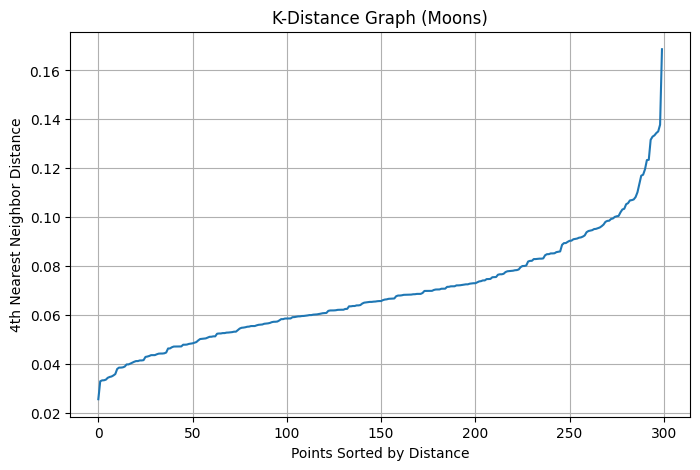

In [6]:
plt.figure(figsize=(8,5))

neighbors = NearestNeighbors(n_neighbors=4)
neighbors.fit(X_moons)

distances, indices = neighbors.kneighbors(X_moons)

distances = np.sort(distances[:,3])

plt.plot(distances)
plt.title("K-Distance Graph (Moons)")
plt.xlabel("Points Sorted by Distance")
plt.ylabel("4th Nearest Neighbor Distance")
plt.grid(True)
plt.show()

# Choose epsilon from elbow point
eps_value = 0.2


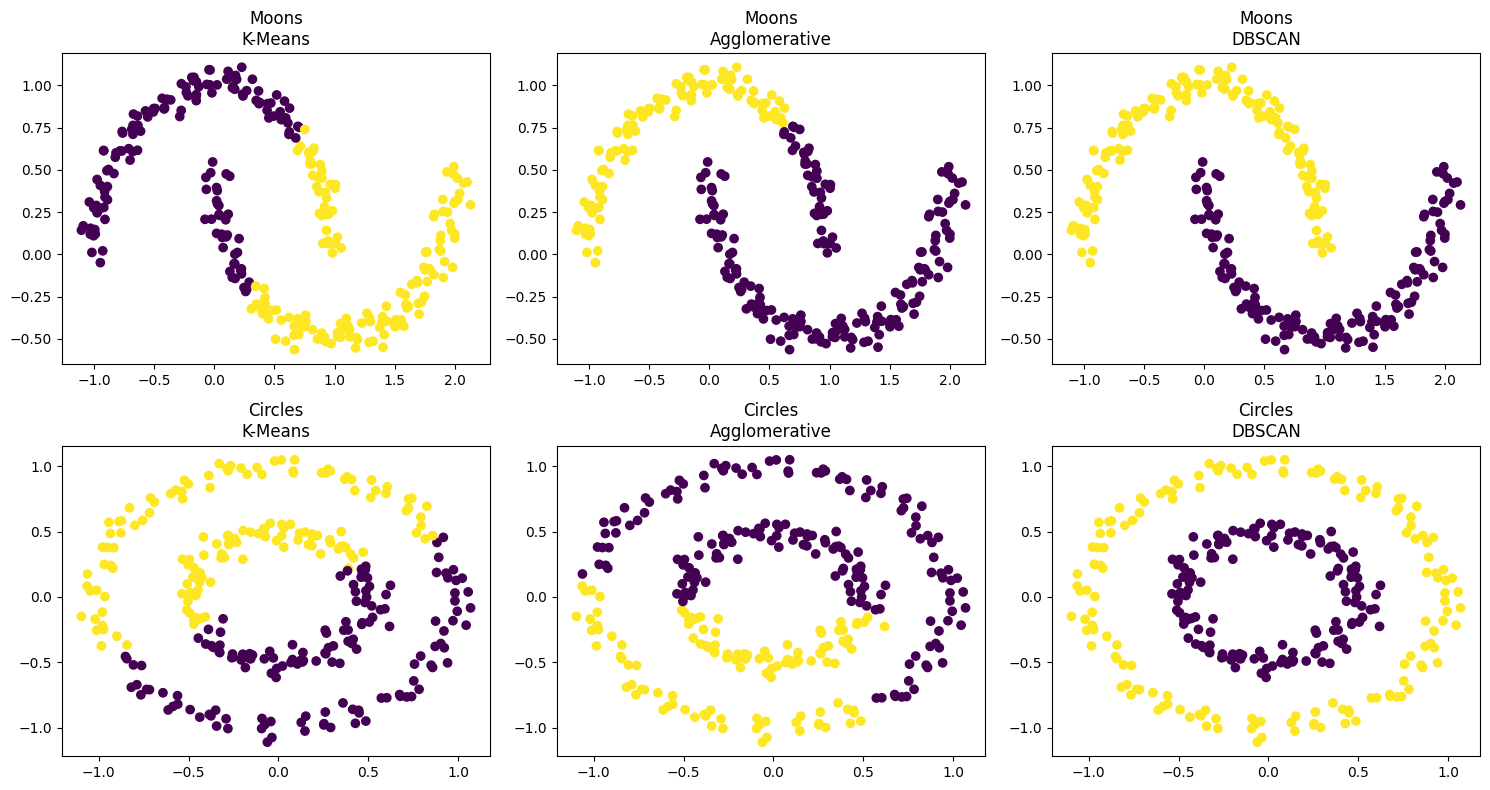

In [7]:
results = []

fig, axes = plt.subplots(2,3, figsize=(15,8))

for row, (dataset_name, X) in enumerate(datasets.items()):

    # ---------------------------
    # KMeans
    # ---------------------------

    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    k_labels = kmeans.fit_predict(X)

    k_score = silhouette_score(X, k_labels)

    results.append([
        dataset_name,
        "K-Means",
        round(k_score,3)
    ])

    axes[row,0].scatter(
        X[:,0],
        X[:,1],
        c=k_labels,
        cmap='viridis'
    )

    axes[row,0].set_title(
        f"{dataset_name}\nK-Means"
    )

    # ---------------------------
    # Agglomerative
    # ---------------------------

    agg = AgglomerativeClustering(
        n_clusters=2
    )

    a_labels = agg.fit_predict(X)

    a_score = silhouette_score(X, a_labels)

    results.append([
        dataset_name,
        "Agglomerative",
        round(a_score,3)
    ])

    axes[row,1].scatter(
        X[:,0],
        X[:,1],
        c=a_labels,
        cmap='viridis'
    )

    axes[row,1].set_title(
        f"{dataset_name}\nAgglomerative"
    )

    # ---------------------------
    # DBSCAN
    # ---------------------------

    dbscan = DBSCAN(
        eps=eps_value,
        min_samples=5
    )

    d_labels = dbscan.fit_predict(X)

    unique_labels = set(d_labels)

    if len(unique_labels) > 1 and len(unique_labels - {-1}) > 1:

        d_score = silhouette_score(X, d_labels)

        results.append([
            dataset_name,
            "DBSCAN",
            round(d_score,3)
        ])

    else:

        results.append([
            dataset_name,
            "DBSCAN",
            "N/A"
        ])

    axes[row,2].scatter(
        X[:,0],
        X[:,1],
        c=d_labels,
        cmap='viridis'
    )

    axes[row,2].set_title(
        f"{dataset_name}\nDBSCAN"
    )

plt.tight_layout()
plt.show()



In [8]:

comparison = pd.DataFrame(
    results,
    columns=[
        "Dataset",
        "Algorithm",
        "Silhouette Score"
    ]
)

print("\nComparison Table")
print(comparison)


Comparison Table
   Dataset      Algorithm  Silhouette Score
0    Moons        K-Means             0.488
1    Moons  Agglomerative             0.441
2    Moons         DBSCAN             0.331
3  Circles        K-Means             0.353
4  Circles  Agglomerative             0.309
5  Circles         DBSCAN             0.110
